# 3. Methode

## ALgemene imports en paden

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_dir = Path("/home/niels/BEP-Niels")

repo_dir = project_dir / "book" / "thesis_projects" / "BSc" / "2026_Q4_NielsEijer_CEG"
bestanden_dir = repo_dir / "Bestanden"
rhine_dir = bestanden_dir / "Rhine"

figures_dir.mkdir(exist_ok=True)

## 3.1 Onderzoeksopzet

Dit onderzoek richt zich op de invloed van klimaatverandering op de lage afvoercondities in het Rijnsysteem. Hiervoor wordt de toekomstige lage afvoer bij Lobith modelmatig bepaald. Vervolgens wordt deze afvoer bij Lobith vertaald naar een verband met de bevaarbaarheid op de IJssel.

Met behulp van eWaterCycle worden afvoerreeksen gegenereerd aan de hand van bestaande modellen. In eerste instantie wordt een model gemaakt om een vergelijking te maken met historische data, om te controleren of het model realistische afvoeren bij Lobith geeft. Vervolgens wordt aan de hand van klimaatscenario’s een analyse gemaakt van toekomstige lage-afvoercondities.

**Figuur 3.1: Schematische weergave van de onderzoeksopzet.**


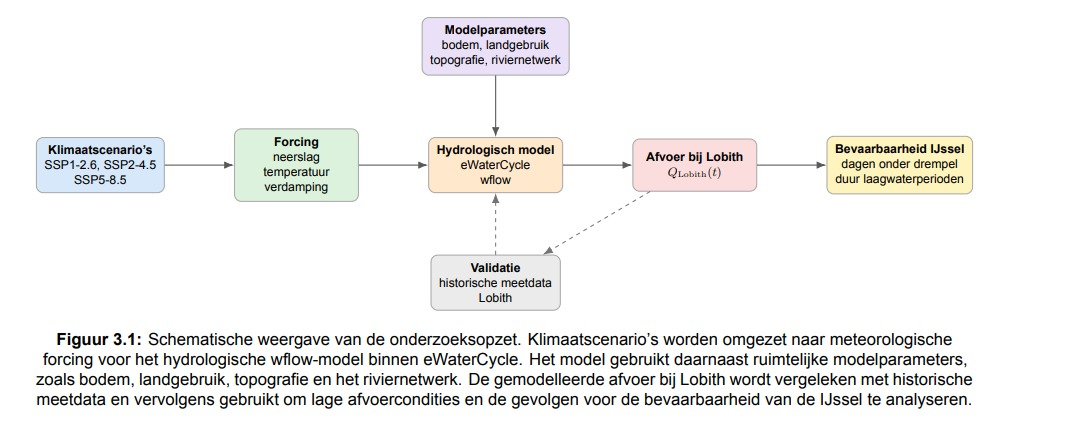

In [5]:
from IPython.display import Image, display
from pathlib import Path

figuur_2_1 = Path("figures/workflow.jpeg")

if figuur_2_1.exists():
    display(Image(filename=str(figuur_2_1)))
else:
    print("Figuur 2.1 is een handmatige/schematische figuur en staat niet als Python-output in deze map.")

## 3.2 Gebruik van eWaterCycle

Voor de modellering van de afvoeren in de toekomst wordt gebruikgemaakt van eWaterCycle. Binnen eWaterCycle kunnen hydrologische modellen vanuit Jupyter-notebooks worden aangestuurd. De modellen worden vervolgens uitgevoerd binnen een containeromgeving, waardoor de modeluitvoering minder afhankelijk wordt van de specifieke installatie op één computer.

In dit onderzoek is gekozen voor wflow. Lage afvoer bij Lobith ontstaat met name door de respons op hydrologische invloeden. wflow is in staat om deze processen ruimtelijk verdeeld door te rekenen, waardoor de afvoer bij Lobith kan worden bepaald als resultaat van meteorologische forcing en gebiedseigenschappen.

De basiscontrole van de wflow-omgeving is:

In [7]:
from ewatercycle.models import Wflow
from ewatercycle.parameter_sets import available_parameter_sets
from ewatercycle.forcing import sources

parameter_sets = available_parameter_sets(target_model="wflow")
parameter_set = parameter_sets["wflow_rhine_sbm_nc"]

parameter_set

ParameterSet(name='wflow_rhine_sbm_nc', directory=PosixPath('/data/shared/parameter-sets/wflow_rhine_sbm_nc'), config=PosixPath('/data/shared/parameter-sets/wflow_rhine_sbm_nc/wflow_sbm_NC.ini'), doi='N/A', target_model='wflow', supported_model_versions={'2020.1.2', '2020.1.3', '2020.1.1'}, downloader=None)

De shapefile voor het Rijnstroomgebied wordt in de run gebruikt als ruimtelijke begrenzing:

In [10]:
shape_file = rhine_dir / "Rhine.shp"
print("Shape bestaat:", shape_file.exists())

Shape bestaat: True


## 3.3 Selectie van klimaatscenario's

Voor de toekomstige analyse worden klimaatscenario’s geselecteerd om een bandbreedte van mogelijke veranderingen in lage-afvoercondities te beschrijven. In dit onderzoek worden drie CMIP6-scenario’s geanalyseerd: SSP1-2.6, SSP2-4.5 en SSP5-8.5.

**Tabel 3.1: Geselecteerde klimaatscenario’s voor dit onderzoek.**

In [11]:
tabel_3_1 = pd.DataFrame([
    {
        "Scenario": "SSP1-2.6",
        "Impactcategorie": "Laag-impact scenario",
        "Betekenis in dit onderzoek": (
            "Scenario met relatief sterke klimaatmitigatie en beperkte verdere opwarming. "
            "Dit scenario wordt gebruikt als ondergrens voor toekomstige veranderingen in lage-afvoercondities."
        )
    },
    {
        "Scenario": "SSP2-4.5",
        "Impactcategorie": "Middel-impact scenario",
        "Betekenis in dit onderzoek": (
            "Scenario met gematigde emissies en gematigde opwarming. "
            "Dit scenario wordt gebruikt als centrale vergelijking tussen een laag en hoog klimaatscenario."
        )
    },
    {
        "Scenario": "SSP5-8.5",
        "Impactcategorie": "Hoog-impact scenario",
        "Betekenis in dit onderzoek": (
            "Scenario met hoge emissies en sterke opwarming. "
            "Dit scenario wordt gebruikt als stresstest voor ongunstige veranderingen in lage-afvoercondities."
        )
    },
])

tabel_3_1

,Scenario,Impactcategorie,Betekenis in dit onderzoek
0,SSP1-2.6,Laag-impact scenario,Scenario met relatief sterke klimaatmitigatie ...
1,SSP2-4.5,Middel-impact scenario,Scenario met gematigde emissies en gematigde o...
2,SSP5-8.5,Hoog-impact scenario,Scenario met hoge emissies en sterke opwarming...


Voor de historische controle wordt gebruikgemaakt van ERA5-data. Voor de toekomstsimulaties wordt uitgegaan van het gekalibreerde wflow-model, waarbij de historische ERA5-forcing wordt aangepast met klimaatsignalen uit de geselecteerde klimaatscenario’s. Op deze manier blijft de ruimtelijke en temporele structuur van de historische forcing behouden, terwijl veranderingen in neerslag, temperatuur en verdamping onder toekomstige klimaatomstandigheden worden meegenomen.

De keuze van het CMIP-model en de scenario’s is in de delta-change notebook vastgelegd als:

In [13]:
chosen_cmip_model = "MPI-ESM1-2-HR"
chosen_cmip_member = "r1i1p1f1"
chosen_cmip_grid = "gn"
chosen_variables = ["pr", "tas"]
chosen_scenarios = ["ssp126", "ssp245", "ssp585"]

cmip_choice = pd.DataFrame({
    "onderdeel": [
        "model",
        "member",
        "grid",
        "variables",
        "scenarios",
        "basis_keuze"
    ],
    "waarde": [
        chosen_cmip_model,
        chosen_cmip_member,
        chosen_cmip_grid,
        ", ".join(chosen_variables),
        ", ".join(chosen_scenarios),
        "Gekozen CMIP6-model en scenario's voor de delta-change methode"
    ]
})

cmip_choice

,onderdeel,waarde
0,model,MPI-ESM1-2-HR
1,member,r1i1p1f1
2,grid,gn
3,variables,"pr, tas"
4,scenarios,"ssp126, ssp245, ssp585"
5,basis_keuze,Gekozen CMIP6-model en scenario's voor de delt...


### Delta-change methode

Voor de toekomstige modelsimulaties is gebruikgemaakt van een delta-change-methode. Hierbij wordt de historische ERA5-forcing niet vervangen door directe CMIP6-modeloutput, maar worden maandelijkse klimaatsignalen toegevoegd aan de ERA5-basisperiode.

De gebruikte perioden zijn:

In [14]:
period_choice = pd.DataFrame({
    "onderdeel": [
        "CMIP historical referentie",
        "CMIP future periode",
        "ERA5/wflow basisperiode",
        "Toekomstige wflow periode"
    ],
    "periode": [
        "1985-2014",
        "2071-2100",
        "1990-2019",
        "2071-2100"
    ],
    "functie": [
        "Bepalen van maandelijkse klimaatsignalen",
        "Bepalen van maandelijkse klimaatsignalen",
        "Dagelijkse basisreeks voor toekomstige forcing",
        "Nieuwe tijdsas voor toekomstige wflow-run"
    ]
})

period_choice

,onderdeel,periode,functie
0,CMIP historical referentie,1985-2014,Bepalen van maandelijkse klimaatsignalen
1,CMIP future periode,2071-2100,Bepalen van maandelijkse klimaatsignalen
2,ERA5/wflow basisperiode,1990-2019,Dagelijkse basisreeks voor toekomstige forcing
3,Toekomstige wflow periode,2071-2100,Nieuwe tijdsas voor toekomstige wflow-run


De maandelijkse klimaatsignalen worden berekend uit historische en toekomstige CMIP-data:

In [15]:
# import xarray as xr
#
# def calculate_monthly_climate_signal(scenario):
#     future_pr = xr.open_dataset(cmip_raw_paths[f"{scenario}_pr"])["pr"]
#     future_tas = xr.open_dataset(cmip_raw_paths[f"{scenario}_tas"])["tas"]
#
#     future_pr = future_pr.where((future_pr >= 0) & (future_pr < 1))
#     future_tas = future_tas.where((future_tas > 150) & (future_tas < 350))
#
#     hist_pr_month = hist_pr.groupby("time.month").mean("time", skipna=True)
#     future_pr_month = future_pr.groupby("time.month").mean("time", skipna=True)
#
#     hist_tas_month = hist_tas.groupby("time.month").mean("time", skipna=True)
#     future_tas_month = future_tas.groupby("time.month").mean("time", skipna=True)
#
#     pr_factor = future_pr_month / hist_pr_month
#     tas_delta = future_tas_month - hist_tas_month
#
#     pr_factor = pr_factor.clip(min=0.2, max=5.0)
#     tas_delta = tas_delta.where((tas_delta > -20) & (tas_delta < 20))
#
#     climate_signal = xr.Dataset({
#         "pr_factor": pr_factor,
#         "tas_delta": tas_delta
#     })
#
#     return climate_signal

De klimaatsignalen worden vervolgens geïnterpoleerd naar het wflow-grid en toegepast op de historische forcing. PET blijft in deze aanpak gelijk aan de historische ERA5-PET.

In [16]:
# def apply_climate_signal_to_forcing(base_forcing, signal, future_start_date):
#     months = xr.DataArray(
#         base_forcing["time"].dt.month.values,
#         dims="time",
#         coords={"time": base_forcing.time}
#     )
#
#     pr_factor = signal["pr_factor"].sel(month=months)
#     tas_delta = signal["tas_delta"].sel(month=months)
#
#     pr_future = base_forcing["pr"] * pr_factor
#     tas_future = base_forcing["tas"] + tas_delta
#     pet_future = base_forcing["pet"]
#
#     future_times = pd.date_range(
#         start=future_start_date,
#         periods=len(base_forcing.time),
#         freq="D"
#     ) + pd.Timedelta(hours=12)
#
#     future_forcing = xr.Dataset({
#         "pr": pr_future,
#         "tas": tas_future,
#         "pet": pet_future
#     })
#
#     future_forcing = future_forcing.assign_coords(
#         time=future_times,
#         lat=base_forcing.lat,
#         lon=base_forcing.lon
#     )
#
#     future_forcing = future_forcing.drop_vars("month", errors="ignore")
#     future_forcing["pr"] = future_forcing["pr"].clip(min=0)
#
#     return future_forcing

Voor de toekomstscenario’s is een spin-upperiode van twee jaar gebruikt. De uiteindelijke analyseperiode loopt van 2071 tot en met 2100.

In [17]:
spinup_start = "2069-01-01"
analysis_start = "2071-01-01"
analysis_end = "2100-12-31"

base_spinup_start = "1988-01-01"
base_spinup_end = "2019-12-31"

Grote future forcing bestanden maken:

In [18]:
# future_temp_forcing_dir = temp_dir / "future_forcing_spinup"
# future_temp_forcing_dir.mkdir(parents=True, exist_ok=True)
#
# spinup_base_forcing = ds_forcing.sel(time=slice("1988-01-01", "2019-12-31"))
#
# def create_spinup_future_forcing_file(scenario):
#     signal = climate_signals_wflow_grid[scenario]
#
#     future_forcing = apply_climate_signal_to_forcing(
#         base_forcing=spinup_base_forcing,
#         signal=signal,
#         future_start_date="2069-01-01"
#     )
#
#     future_forcing = future_forcing.sel(time=slice("2069-01-01", "2100-12-31"))
#
#     output_file = future_temp_forcing_dir / f"wflow_forcing_{scenario}_2069_2100_uncompressed.nc"
#
#     encoding = {
#         "pr": {"dtype": "float32"},
#         "tas": {"dtype": "float32"},
#         "pet": {"dtype": "float32"}
#     }
#
#     future_forcing.to_netcdf(output_file, encoding=encoding)
#     future_forcing.close()
#
#     return output_file

## 3.4 Kalibratie en validatie van het model

Voor de kalibratie en validatie van het model is gekozen voor ongeveer 50% van de beschikbare periode voor de kalibratie en ongeveer 50% voor de validatie. De kalibratie is uitgevoerd voor 1987-2003, waarna de modelprestatie is getoetst voor 2004-2019.

In [19]:
calibration_start = "1987-01-01"
calibration_end = "2003-12-31"

validation_start = "2004-01-01"
validation_end = "2019-12-31"

### 3.4.1 Kalibratie-validatie indicatoren

Om de modellen te beoordelen wordt gebruikgemaakt van RMSE, bias, log-NSE, laagwaterpercentielen en het aantal dagen onder drempelwaarden.

**Tabel 3.2: Prestatie-indicatoren voor de kalibratie en validatie van de gemodelleerde Lobith-afvoer.**

In [20]:
tabel_3_2 = pd.DataFrame([
    {
        "Indicator": "RMSE",
        "Wat wordt vergeleken?": "Gemodelleerde en gemeten dagafvoer",
        "Doel binnen dit onderzoek": (
            "Bepaalt de gemiddelde grootte van de modelfout. "
            "De RMSE wordt gebruikt als algemene controle op de overeenkomst tussen model en meting."
        )
    },
    {
        "Indicator": "Bias",
        "Wat wordt vergeleken?": "Gemiddelde afwijking tussen model en meting",
        "Doel binnen dit onderzoek": (
            "Geeft aan of het model de afvoer systematisch overschat of onderschat."
        )
    },
    {
        "Indicator": "Log-NSE",
        "Wat wordt vergeleken?": "Modelprestatie op logaritmische schaal",
        "Doel binnen dit onderzoek": (
            "Beoordeelt de modelprestatie met relatief meer nadruk op lage afvoeren."
        )
    },
    {
        "Indicator": "Laagwaterpercentielen",
        "Wat wordt vergeleken?": "Percentielen van gemodelleerde en gemeten afvoer",
        "Doel binnen dit onderzoek": (
            "Controleert of het model het lage-afvoerbereik goed reproduceert."
        )
    },
    {
        "Indicator": "Dagen onder drempelwaarde",
        "Wat wordt vergeleken?": "Aantal dagen met Q < Q*",
        "Doel binnen dit onderzoek": (
            "Telt het aantal dagen waarop de afvoer onder een gekozen laagwatergrens valt."
        )
    },
])

tabel_3_2

,Indicator,Wat wordt vergeleken?,Doel binnen dit onderzoek
0,RMSE,Gemodelleerde en gemeten dagafvoer,Bepaalt de gemiddelde grootte van de modelfout...
1,Bias,Gemiddelde afwijking tussen model en meting,Geeft aan of het model de afvoer systematisch ...
2,Log-NSE,Modelprestatie op logaritmische schaal,Beoordeelt de modelprestatie met relatief meer...
3,Laagwaterpercentielen,Percentielen van gemodelleerde en gemeten afvoer,Controleert of het model het lage-afvoerbereik...
4,Dagen onder drempelwaarde,Aantal dagen met Q < Q*,Telt het aantal dagen waarop de afvoer onder e...


De indicatoren zijn in code als volgt gedefinieerd:


In [21]:
def rmse(obs, sim):
    obs = np.asarray(obs)
    sim = np.asarray(sim)
    return np.sqrt(np.mean((sim - obs) ** 2))


def bias(obs, sim):
    obs = np.asarray(obs)
    sim = np.asarray(sim)
    return np.mean(sim - obs)


def log_nse(obs, sim):
    obs = np.asarray(obs)
    sim = np.asarray(sim)

    obs_log = np.log(obs)
    sim_log = np.log(sim)

    teller = np.sum((obs_log - sim_log) ** 2)
    noemer = np.sum((obs_log - obs_log.mean()) ** 2)

    return 1 - teller / noemer


def count_days_below(data, discharge_col, threshold):
    return (data[discharge_col] < threshold).sum()

### 3.4.2 Seizoensafhankelijke biascorrectie op modeloutput

Omdat de kalibratie en validatie van het wflow-model niet goed genoeg scoren op de prestatie-indicatoren, is gekozen voor een biascorrectie op de modeloutput. Hiervoor is gebruikgemaakt van een seizoensafhankelijke quantile-mapping biascorrectie op basis van flow duration curves.

De correctie wordt afgeleid op de kalibratieperiode (1987-2003) en vervolgens getest op de onafhankelijke validatieperiode (2004-2019). De correctie wordt opgedeeld in vier seizoenen: winter, lente, zomer en herfst. Per seizoen is in de kalibratie de afvoerverdeling bepaald van wflow-afvoer en gemeten GRDC-afvoer. Hiervoor zijn 101 kwantielen gebruikt.


In [22]:
def add_seasons(data):
    data = data.copy()
    data["month"] = data["date"].dt.month

    data["season"] = "unknown"
    data.loc[data["month"].isin([12, 1, 2]), "season"] = "winter"
    data.loc[data["month"].isin([3, 4, 5]), "season"] = "lente"
    data.loc[data["month"].isin([6, 7, 8]), "season"] = "zomer"
    data.loc[data["month"].isin([9, 10, 11]), "season"] = "herfst"

    return data

In [23]:
def apply_four_season_qm(data, relation_table):
    data = data.copy()
    relation_table = relation_table.copy()

    if "group" in relation_table.columns:
        relation_table = relation_table.rename(columns={"group": "season"})

    data["Q_model_biascorrected_m3s"] = np.nan

    for season in ["winter", "lente", "zomer", "herfst"]:
        season_relation = relation_table[
            relation_table["season"] == season
        ].copy()

        season_relation = season_relation.sort_values("model_q")

        model_q = season_relation["model_q"].values
        grdc_q = season_relation["grdc_q"].values

        mask = data["season"] == season

        data.loc[mask, "Q_model_biascorrected_m3s"] = np.interp(
            data.loc[mask, "Q_model_raw_m3s"],
            model_q,
            grdc_q
        )

    return data

De gebruikte correctierelatie staat in:

In [24]:
relation_file = bestanden_dir / "lobith_four_season_qm_relation.csv"
four_relation = pd.read_csv(relation_file)

four_relation.head()

,season,quantile,model_q,grdc_q
0,winter,0.00,378.058990,855.00
1,winter,0.01,489.880028,933.65
2,winter,0.02,573.746072,1052.62
3,winter,0.03,671.807537,1098.98
4,winter,0.04,744.721763,1127.32


## 3.5 Definitie van lage-afvoercondities

Na de kalibratie en validatie van de afvoerreeksen bij Lobith kan het model worden gebruikt om aan de hand van klimaatscenario’s voorspellingen te maken voor de afvoer bij Lobith in de toekomst. Om lage afvoercondities te beschrijven, worden laagwaterpercentielen bepaald. Hiervoor worden onder andere q10, q5 en q1 gebruikt.

Naast deze percentielen wordt gewerkt met een vaste laagwaterdrempel. Hiervoor wordt de Overeengekomen Lage Afvoer van 1.020 m3/s bij Lobith gebruikt. Deze drempel wordt in dit onderzoek gezien als hydrologische indicator voor lage afvoer, maar niet als grenswaarde voor onvoldoende vaardiepte op de IJssel.

In [26]:
lowflow_percentiles = [1, 5, 10, 17, 25, 50]
ola_threshold = 1020

def calculate_percentiles(data, discharge_col, percentiles):
    rows = []

    for percentile in percentiles:
        rows.append({
            "percentile": percentile,
            "discharge_m3s": data[discharge_col].quantile(percentile / 100)
        })

    return pd.DataFrame(rows)

Voor de analyse van aaneengesloten laagwaterperioden wordt bepaald wanneer opeenvolgende dagen onder de drempel liggen.


In [27]:
def find_lowflow_events(data, discharge_col, threshold):
    data = data.copy().sort_values("date")
    data["below_threshold"] = data[discharge_col] < threshold

    events = []
    current_start = None
    current_length = 0
    previous_date = None

    for _, row in data.iterrows():
        if row["below_threshold"]:
            if current_start is None:
                current_start = row["date"]
                current_length = 1
            else:
                current_length += 1
        else:
            if current_start is not None:
                events.append({
                    "start_date": current_start,
                    "end_date": previous_date,
                    "duration_days": current_length
                })
                current_start = None
                current_length = 0

        previous_date = row["date"]

    if current_start is not None:
        events.append({
            "start_date": current_start,
            "end_date": previous_date,
            "duration_days": current_length
        })

    return pd.DataFrame(events)

## 3.6 Afvoerverdeling en bevaarbaarheidsindicator voor de IJssel

Zoals eerder beschreven bepaalt de afvoerverdeling bij Lobith niet direct de bevaarbaarheid op de IJssel. Omdat de afvoerverdeling bij de Pannerdense Kop en de IJsselkop vooral een hydraulisch vraagstuk is, wordt in dit onderzoek geen model gebruikt om deze verdeling te bepalen. In plaats daarvan wordt de mogelijke verandering in afvoerverdeling meegenomen via drie drempelvarianten.

**Tabel 3.3: Drempelvarianten voor de gevoeligheidsanalyse van veranderende afvoerverdeling richting de IJssel.**

In [28]:
tabel_3_3 = pd.DataFrame([
    {
        "Variant": "OLA-scenario",
        "Interpretatie": (
            "Geen correctie voor veranderende afvoerverdeling. "
            "De Overeengekomen Lage Afvoer bij Lobith wordt gebruikt als vaste referentiedrempel."
        ),
        "Drempel Lobith": 1020
    },
    {
        "Variant": "10%-scenario",
        "Interpretatie": (
            "Matige gevoeligheidsvariant waarin de IJssel onder lage afvoercondities "
            "relatief 10% minder water ontvangt."
        ),
        "Drempel Lobith": 1133
    },
    {
        "Variant": "17%-scenario",
        "Interpretatie": (
            "Sterke gevoeligheidsvariant waarin de IJssel onder lage-afvoercondities "
            "relatief 17% minder water ontvangt."
        ),
        "Drempel Lobith": 1229
    },
])

tabel_3_3

,Variant,Interpretatie,Drempel Lobith
0,OLA-scenario,Geen correctie voor veranderende afvoerverdeli...,1020
1,10%-scenario,Matige gevoeligheidsvariant waarin de IJssel o...,1133
2,17%-scenario,Sterke gevoeligheidsvariant waarin de IJssel o...,1229


Deze drempels zijn geen officiële OLA-waarden. Ze worden gebruikt om ook de impact van de veranderende afvoerverdeling mee te nemen.

In de resultatenanalyse worden deze drempels gebruikt als:


In [29]:
thresholds = [1020, 1133, 1229]


## 3.7 Aannames en methodische beperkingen

De resultaten worden geïnterpreteerd als indicator voor laagwaterdruk op de IJssel, niet als directe berekening van lokale vaardieptes. Een dag waarop de afvoer onder de drempel van het OLA-, 10%- of 17%-scenario ligt, wordt beschouwd als een kritieke laagwaterdag. Voor ieder klimaatscenario en iedere drempelvariant worden het aantal kritieke dagen en de duur daarvan bepaald.

De werkelijke bevaarbaarheid hangt echter ook af van lokale bodemligging, sedimentatie, vaargeulbreedte en onderhoud van de vaarweg. De resultaten moeten daarom worden gelezen als kwantitatieve indicatie van verhoogd bevaarbaarheidsrisico en niet als exacte voorspelling van onbevaarbaarheid.